# What selects a PPI path, and what survives filtering?

This companion separates **minimum-cost path selection**, **post-selection tortuosity filtering**, and **thresholding the resulting votes**. It reads the saved [path diagnostics](../docs/benchmarks/diagnostics/README.md) and the existing [multiline study](../docs/benchmarks/multiline/README.md). The original studies, package defaults, and public API remain unchanged.

Laurent's blank-image observation is correct: admissible paths still exist everywhere, so nonzero votes are expected. A blank vote map is not, by itself, evidence of a correctness bug. The separate questions are how tied optima and boundaries distribute those votes, and why a weak line loses evidence beside a strong line.

These are bounded synthetic diagnostics, not an exact reproduction of MICCAI 2012 or a clinical validation. The original MICCAI 2012 dataset is not public.

## Run the saved analysis

From a repository clone, install `python -m pip install '.[study,notebook]'`, then open `python -m jupyter lab examples/ppi_path_diagnostics.ipynb` and run all cells in order.

The notebook reads committed JSON, redraws scalar figures, regenerates only the small synthetic image backgrounds for the fixed path gallery, and embeds the saved blank-map PNG. It does not rerun the PPI core. No private dataset or local NPZ cache is required. The [diagnostic report](../docs/benchmarks/diagnostics/README.md) documents separate commands for rerunning measurements.

In [1]:
import hashlib
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, Markdown, display

ROOT = Path.cwd().resolve()
if not (ROOT / "benchmarks").is_dir():
    ROOT = ROOT.parent
if not (ROOT / "benchmarks" / "plot_path_diagnostics.py").is_file():
    raise FileNotFoundError("Run from the repository root or examples directory.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from benchmarks.plot_path_diagnostics import (  # noqa: E402
    plot_blank_summary,
    plot_source_paths,
    plot_weak_stages,
)

DIRECTORY = ROOT / "docs" / "benchmarks" / "diagnostics"

def table(headers, rows):
    def fmt(value):
        if value is None:
            return "—"
        if isinstance(value, (float, np.floating)):
            return f"{value:.2f}"
        return str(value)
    lines = [" | ".join(headers), " | ".join(["---"] * len(headers))]
    lines.extend(" | ".join(fmt(value) for value in row) for row in rows)
    display(Markdown("\n".join(lines)))

In [2]:
weak = json.loads((DIRECTORY / "weak-paths.json").read_text())
blank = json.loads((DIRECTORY / "blank-paths.json").read_text())
contexts = weak["protocol"]["contexts"]
scenarios = [("weak_alone", None, "Alone"),
             ("weak_near_strong", 6, "Gap 6"),
             ("weak_near_strong", 10, "Gap 10")]
stages = [("unfiltered", "Before filter"),
          ("tau_0.75", "τ ≥ 0.75"), ("tau_0.5", "τ ≥ 0.50")]

def group(potential, family, gap):
    return [r for r in weak["results"] if r["potential"] == potential
            and r["family"] == family and r["gap"] == gap]

assert len(weak["results"]) == len(contexts) * 3 * 2 == 54
assert len({(r["case_id"], r["potential"]) for r in weak["results"]}) == 54
assert all(len(group(p, f, g)) == 9
           for p in ("raw", "local") for f, g, _ in scenarios)
table(["Evidence", "Scope", "Recorded UTC time"], [
    ["Weak-line paths", "9 contexts × 3 scenes × 2 potentials", weak["created_at_utc"]],
    ["Blank/tie diagnostics", f"{blank['core_case_count']} core cases; {blank['vote_map_count']} vote maps",
     blank["generated_at_utc"]],
])

Evidence | Scope | Recorded UTC time
--- | --- | ---
Weak-line paths | 9 contexts × 3 scenes × 2 potentials | 2026-09-26T13:06:00.623712+00:00
Blank/tie diagnostics | 8 core cases; 20 vote maps | 2026-09-26T13:04:52.612022+00:00

## Weak-line evidence is lost in two stages

Each of the nine existing contexts compares the same weak geometry and exact same noise realization alone, beside a strong line at gap 6, and beside one at gap 10. The nine contexts reuse three noise seeds across orientations; they are **paired contexts, not nine independent replications**. The weak-alone case is shared by both gap comparisons. Weak-band pixel intensities are identical in the original uint8 paired images before preprocessing; the local-contrast potential can change there because its Gaussian background estimate includes the added neighbor.

The core selects one minimum-cost path per source. The tortuosity filter then retains or rejects that already selected path; it does not search for a straighter alternative. “Weak origins” are source pixels within 2 pixels of the weak reference. Visiting the strong tube means touching its finite 3σ support, not necessarily remaining there for the whole path.

The first table pools source counts across contexts. The second gives equal-context means, including each context's mean votes per weak-band pixel. Coverage is reference arclength within 2 pixels of selected pixels. A positive vote and a vote **strictly greater than 56** are distinct criteria. The cutoff comes from the preceding study: the unfiltered and raw-relaxed rows are diagnostic comparisons, not newly calibrated accuracy estimates.

In [3]:
source_rows, stage_rows = [], []
for potential in ("raw", "local"):
    for family, gap, label in scenarios:
        records = group(potential, family, gap)
        total = sum(r["weak_origin_count"] for r in records)
        visits = sum(r["weak_origin_visits_strong_support"] for r in records)
        source_rows.append([potential, label, total, visits, 100 * visits / total])
        for key, stage_label in stages:
            values = [r["stages"][key] for r in records]
            stage_rows.append([
                potential, label, stage_label,
                np.mean([v["weak_band_score_distribution"]["mean"] for v in values]),
                sum(v["weak_origin_retained"] for v in values),
                100 * np.mean([v["positive_vote_weak_coverage"] for v in values]),
                100 * np.mean([v["threshold_coverage"]["56"]["weak_coverage"] for v in values]),
            ])
table(["Potential", "Scene", "Weak origins", "Visit strong tube", "Visit (%)"], source_rows)
table(["Potential", "Scene", "Stage", "Mean votes/pixel", "Weak origins kept",
       "Coverage: >0 (%)", "Coverage: >56 (%)"], stage_rows)

Potential | Scene | Weak origins | Visit strong tube | Visit (%)
--- | --- | --- | --- | ---
raw | Alone | 2130 | 0 | 0.00
raw | Gap 6 | 2130 | 2130 | 100.00
raw | Gap 10 | 2130 | 2130 | 100.00
local | Alone | 2130 | 0 | 0.00
local | Gap 6 | 2130 | 2130 | 100.00
local | Gap 10 | 2130 | 2130 | 100.00

Potential | Scene | Stage | Mean votes/pixel | Weak origins kept | Coverage: >0 (%) | Coverage: >56 (%)
--- | --- | --- | --- | --- | --- | ---
raw | Alone | Before filter | 392.44 | 2130 | 100.00 | 100.00
raw | Alone | τ ≥ 0.75 | 19.78 | 192 | 93.45 | 57.08
raw | Alone | τ ≥ 0.50 | 87.39 | 712 | 100.00 | 82.64
raw | Gap 6 | Before filter | 45.04 | 2130 | 100.00 | 68.19
raw | Gap 6 | τ ≥ 0.75 | 3.77 | 82 | 96.07 | 0.00
raw | Gap 6 | τ ≥ 0.50 | 13.91 | 635 | 100.00 | 2.03
raw | Gap 10 | Before filter | 46.25 | 2130 | 100.00 | 76.40
raw | Gap 10 | τ ≥ 0.75 | 3.60 | 50 | 89.41 | 0.00
raw | Gap 10 | τ ≥ 0.50 | 13.08 | 598 | 99.31 | 5.05
local | Alone | Before filter | 385.62 | 2130 | 100.00 | 100.00
local | Alone | τ ≥ 0.75 | 19.86 | 198 | 92.19 | 58.92
local | Alone | τ ≥ 0.50 | 87.75 | 713 | 100.00 | 82.67
local | Gap 6 | Before filter | 38.80 | 2130 | 100.00 | 44.49
local | Gap 6 | τ ≥ 0.75 | 3.36 | 70 | 89.16 | 0.00
local | Gap 6 | τ ≥ 0.50 | 13.24 | 593 | 99.56 | 0.99
local | Gap 10 | Before filter | 34.33 | 2130 | 100.00 | 41.50
local | Gap 10 | τ ≥ 0.75 | 2.96 | 52 | 83.60 | 0.00
local | Gap 10 | τ ≥ 0.50 | 11.09 | 607 | 99.06 | 0.00

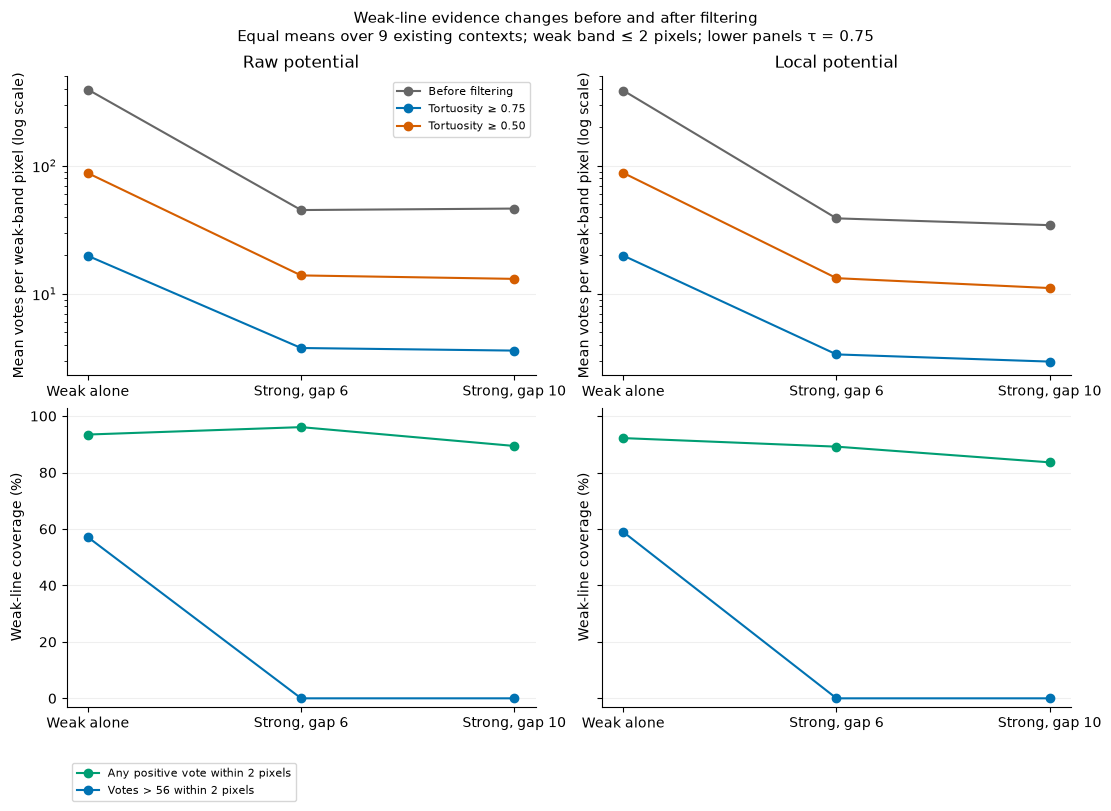

In [4]:
fig = plot_weak_stages(weak)
plt.show()
plt.close(fig)

## A fixed illustration: score distribution and selected paths

The following table and gallery use the **first declared context**, raw potential, and the three fixed scene variants. This illustration is not a best- or worst-case selection. Quantiles are the actual distributions for this context, never averages of quantiles from different scenes.

The score distribution samples the nearest image pixel to each weak-reference sample; repeated pixels can occur. “Zero arclength” uses trapezoidal reference weights at nearest pixels with zero votes. It is different from tolerance-based coverage: a reference point can have a zero nearest pixel but still lie within 2 pixels of another pixel with a positive vote. Thus 100% positive-vote coverage in an illustration does not imply positive votes at every nearest pixel, nor that all nine contexts reach 100%.

In [5]:
first_context = contexts[0]
quantile_rows = []
for family, gap, label in scenarios:
    record = next(r for r in group("raw", family, gap) if r["pair_group"] == first_context)
    for key, stage_label in stages:
        stage = record["stages"][key]
        q = stage["weak_reference_nearest_pixel_score_distribution"]
        quantile_rows.append([
            label, stage_label, q["q25"], q["median"], q["q75"], q["q95"],
            100 * stage["zero_vote_reference_fraction"],
            100 * stage["positive_vote_weak_coverage"],
            100 * stage["threshold_coverage"]["56"]["weak_coverage"],
        ])
display(Markdown(f"**Fixed context:** `{first_context}`"))
table(["Scene", "Stage", "Q25", "Median", "Q75", "Q95", "Zero arclength (%)",
       "Coverage: >0 (%)", "Coverage: >56 (%)"], quantile_rows)

**Fixed context:** `evaluation_a000_s2001_n05`

Scene | Stage | Q25 | Median | Q75 | Q95 | Zero arclength (%) | Coverage: >0 (%) | Coverage: >56 (%)
--- | --- | --- | --- | --- | --- | --- | --- | ---
Alone | Before filter | 216.00 | 908.00 | 1471.00 | 1681.40 | 0.00 | 100.00 | 100.00
Alone | τ ≥ 0.75 | 7.00 | 53.00 | 174.00 | 253.20 | 5.58 | 100.00 | 81.03
Alone | τ ≥ 0.50 | 97.00 | 348.00 | 837.00 | 1124.20 | 0.00 | 100.00 | 100.00
Gap 6 | Before filter | 26.00 | 36.00 | 43.00 | 131.40 | 0.00 | 100.00 | 56.03
Gap 6 | τ ≥ 0.75 | 1.00 | 3.00 | 6.00 | 11.80 | 17.86 | 100.00 | 0.00
Gap 6 | τ ≥ 0.50 | 12.00 | 19.00 | 24.00 | 34.80 | 0.00 | 100.00 | 9.38
Gap 10 | Before filter | 29.00 | 38.00 | 44.00 | 158.20 | 0.00 | 100.00 | 82.14
Gap 10 | τ ≥ 0.75 | 2.00 | 5.00 | 7.00 | 11.60 | 10.71 | 100.00 | 0.00
Gap 10 | τ ≥ 0.50 | 15.00 | 21.00 | 28.00 | 37.80 | 0.00 | 100.00 | 17.86

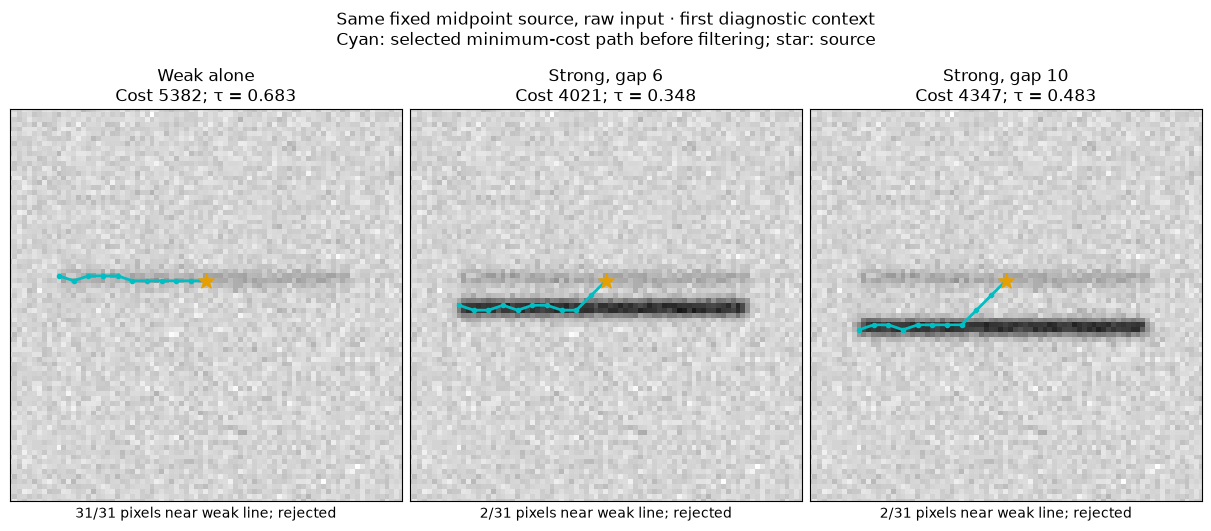

In [6]:
fig = plot_source_paths(weak)
plt.show()
plt.close(fig)

The cyan path is the selected optimum from the same fixed weak-line midpoint source. It is drawn **before filtering**, including paths later rejected at τ = 0.75. The star is the source; all coordinates in the saved record use `(row, column)`. The caption counts raster-pixel occurrences within 2 pixels of the weak line, including the source and counting shared segment joints once. A single illustration helps locate the mechanism; the all-context tables provide its scope.

## Uniform images: every feasible path has the same cost

For constant potential **c**, segment length **L = 3**, and **K = 10** segments:

**Cost: C = L × K × c = 30c.**  
**Vote occurrences per retained path: L × K + 1 = 31.**

The extra vote is the source pixel. The API chooses **one** optimal path per source, rather than enumerating every tied optimum. Therefore votes are expected even without a line. The unchanged implementation chooses the last equal-cost endpoint within each cone and the first equal-cost cone across H, B, E, W. This tie policy and the finite canvas can create spatially uneven votes.

The next table uses the same centered 80 × 80 ROI at three canvas sizes. Strictly `votes > 56` and `votes > 58` are historical cutoffs, not calibrated blank-image error guarantees. On the 256 × 256 canvas the center ROI is uniformly **31**, so removing threshold exceedances does not mean removing expected votes.

In [7]:
uniform = [c for c in blank["cases"] if c["seed"] is None]
assert all(c["uniform_cost_check"]["all_finite_costs_match"] for c in uniform)
assert all(m["vote_conservation_holds"] for c in blank["cases"] for m in c["vote_maps"])
assert all(r["paths_identical_to_intensity_200"] and r["retained_masks_identical"]
           and r["votes_identical"] for r in blank["constant_intensity_comparisons"])
display(Markdown("**Checks passed:** all uniform finite costs equal `30 × intensity`; "
                 "every map conserves 31 votes per retained path; paths, retention masks "
                 "and votes agree at constants 0, 100, 200 and 255 on the 128 canvas."))
blank_rows = []
for case in uniform:
    if case["intensity"] != 200:
        continue
    for mapping in case["vote_maps"]:
        if mapping["tortuosity_threshold"] is None:
            continue
        roi = mapping["center_roi"]
        blank_rows.append([
            case["size"], mapping["tortuosity_threshold"], mapping["retained_sources"],
            roi["minimum"], roi["maximum"], roi["mean"],
            roi["count_strictly_above_56"], 100 * roi["count_strictly_above_56"] / roi["pixels"],
            roi["count_strictly_above_58"],
        ])
table(["Canvas side", "τ cutoff", "Paths kept (whole canvas)", "ROI min", "ROI max",
       "ROI mean", "ROI >56", "ROI >56 (%)", "ROI >58"], blank_rows)

**Checks passed:** all uniform finite costs equal `30 × intensity`; every map conserves 31 votes per retained path; paths, retention masks and votes agree at constants 0, 100, 200 and 255 on the 128 canvas.

Canvas side | τ cutoff | Paths kept (whole canvas) | ROI min | ROI max | ROI mean | ROI >56 | ROI >56 (%) | ROI >58
--- | --- | --- | --- | --- | --- | --- | --- | ---
128 | 0.50 | 16384 | 25 | 61 | 38.00 | 507 | 7.92 | 281
128 | 0.75 | 15232 | 23 | 61 | 37.94 | 502 | 7.84 | 281
192 | 0.50 | 36864 | 31 | 35 | 31.12 | 0 | 0.00 | 0
192 | 0.75 | 35136 | 31 | 35 | 31.12 | 0 | 0.00 | 0
256 | 0.50 | 65536 | 31 | 31 | 31.00 | 0 | 0.00 | 0
256 | 0.75 | 63232 | 31 | 31 | 31.00 | 0 | 0.00 | 0

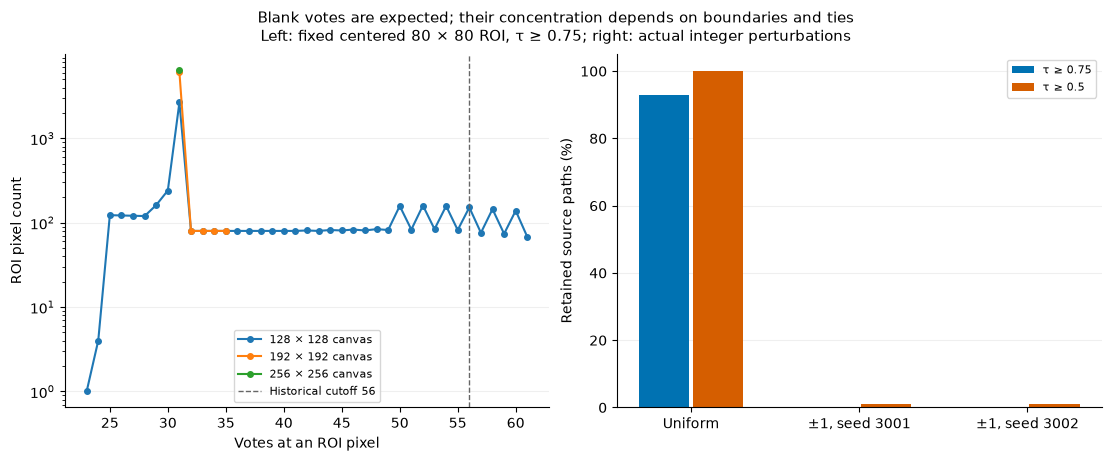

In [8]:
fig = plot_blank_summary(blank)
plt.show()
plt.close(fig)

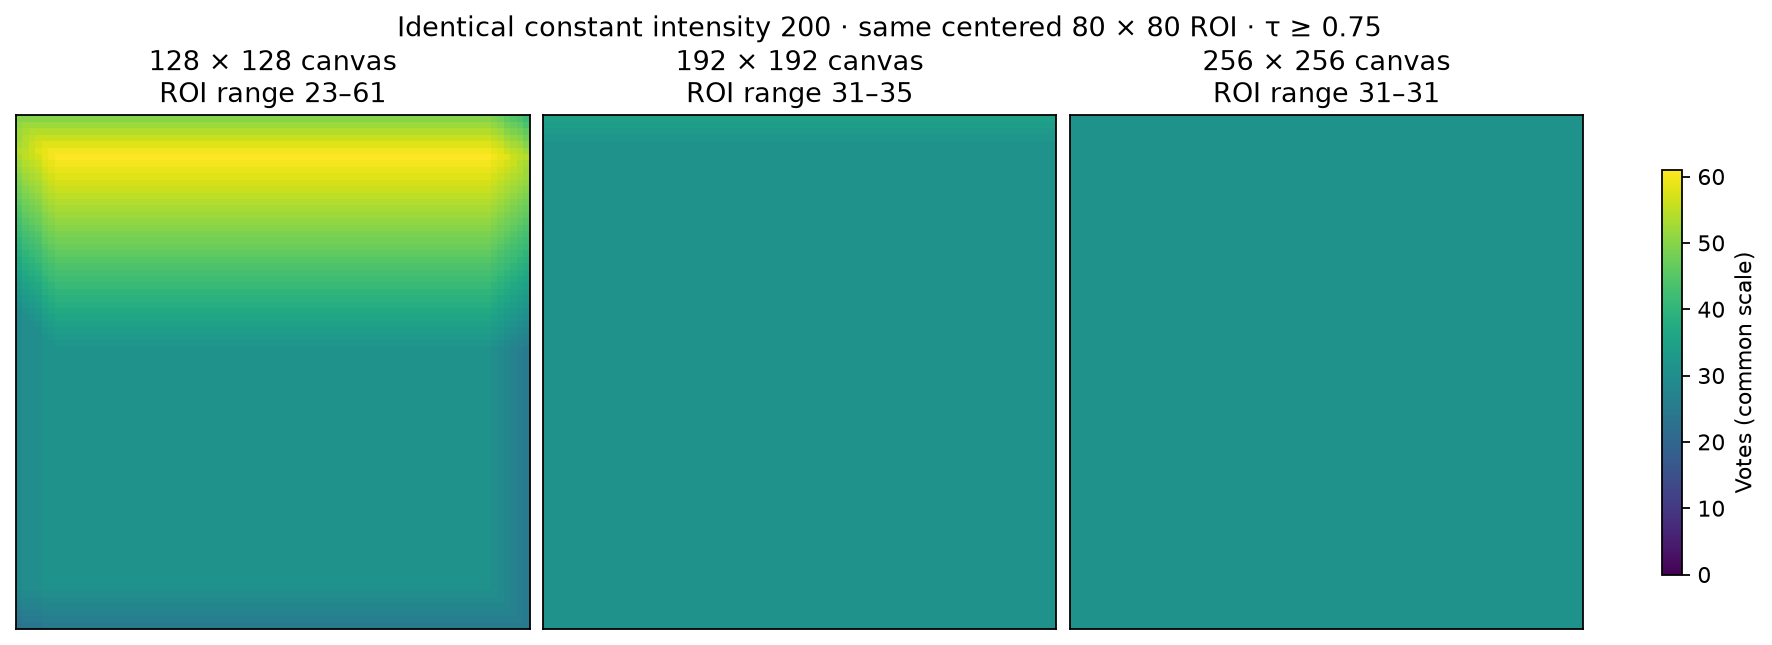

In [9]:
# The spatial figure needs the optional NPZ cache to regenerate; its committed PNG
# is embedded here. All numeric summaries above are recomputed from committed JSON.
display(Image(filename=str(DIRECTORY / "assets" / "blank-maps.png")))

At fixed ROI size, increasing the surrounding canvas changes the path boundary conditions. The 128-canvas default filter has 502 of 6400 ROI pixels above 56 (7.84375%); the 256-canvas ROI has no such exceedances and remains nonzero throughout. This comparison diagnoses spatial concentration of expected votes, not line detection on the blank.

## Tiny integer perturbations alter tied selections

The perturbations are actual integer offsets drawn from {−1, 0, +1}, producing uint8 values 199, 200 and 201; they are not floating perturbations lost during quantization. They break many original ties but do **not** guarantee unique optima. Changing selected paths can change tortuosity and hence path retention. The two seeded examples are a sensitivity check, not an estimate of real-image performance.

In [10]:
perturbation_rows = []
for record in blank["integer_perturbation_comparisons"]:
    case = next(c for c in blank["cases"] if c["seed"] == record["seed"])
    mapping = next(m for m in case["vote_maps"] if m["filter"] == record["filter"])
    roi = mapping["center_roi"]
    perturbation_rows.append([
        record["seed"], mapping["tortuosity_threshold"],
        100 * record["source_paths_changed_fraction"],
        mapping["retained_sources"], roi["maximum"],
        roi["count_strictly_above_56"], roi["count_strictly_above_58"],
    ])
table(["Seed", "τ cutoff", "Source paths changed (%)", "Paths kept (whole canvas)",
       "ROI max", "ROI >56", "ROI >58"], perturbation_rows)

Seed | τ cutoff | Source paths changed (%) | Paths kept (whole canvas) | ROI max | ROI >56 | ROI >58
--- | --- | --- | --- | --- | --- | ---
3001 | 0.50 | 100.00 | 155 | 41 | 0 | 0
3001 | 0.75 | 100.00 | 5 | 4 | 0 | 0
3002 | 0.50 | 100.00 | 147 | 30 | 0 | 0
3002 | 0.75 | 100.00 | 4 | 3 | 0 | 0

## Diagnostic provenance

Both reports identify the executed source and compiled kernel by SHA-256, including diagnostic files added after the recorded Git revision. The following check verifies the current measured-source files against those records. It does not equate a new machine's compiled binary with the recorded binary; compiler and platform can change that hash.

In [11]:
source_expectations = dict(blank["provenance"]["source_sha256"])
for name, expected in weak["provenance"]["implementation_source_sha256"].items():
    source_expectations[f"src/polygonal_path_image/{name}"] = expected
for category in ("benchmark_source_sha256", "diagnostic_source_sha256"):
    for name, expected in weak["provenance"][category].items():
        source_expectations[f"benchmarks/{name}"] = expected
mismatches = [name for name, expected in source_expectations.items()
              if hashlib.sha256((ROOT / name).read_bytes()).hexdigest() != expected]
assert not mismatches, f"Measured source differs from saved diagnostics: {mismatches}"
assert all(r[key] for r in weak["results"] for key in
           ("all_path_costs_verified", "all_stage_votes_verified", "all_source_partitions_verified"))
assert weak["provenance"]["compiled_kernel_sha256"] == blank["provenance"]["compiled_kernel_sha256"]
table(["Evidence file", "SHA-256"], [
    [name, hashlib.sha256((DIRECTORY / name).read_bytes()).hexdigest()]
    for name in ("weak-paths.json", "blank-paths.json")
])
display(Markdown(f"**Verified {len(source_expectations)} source files.** "
                 "All 54 weak-line records report cost, stage-vote and source-partition checks passed. "
                 "Both diagnostics record the same compiled-kernel hash."))

Evidence file | SHA-256
--- | ---
weak-paths.json | 68f63c900f2a4d796e719b8f04880b7e97f2597fd4b83f3027d43eb7c84edc03
blank-paths.json | 67d91c820096c5e57f06283c63ffccb83415b4cc626e3ed6fbb799e1dce573ab

**Verified 10 source files.** All 54 weak-line records report cost, stage-vote and source-partition checks passed. Both diagnostics record the same compiled-kernel hash.

## One frozen straight-path fallback on fresh cases

The benchmark-only candidate **keeps every original winner accepted at τ ≥ 0.75**. For a rejected finite source, it chooses the cheapest feasible straight path among 24 fixed displacements, each repeated ten times. Impossible sources remain inactive. This is a restricted fallback, not a globally optimal tortuosity-constrained path; it favors straight structures and does not suppress blank votes or apply an intensity gate. It is **experimental, outside the package defaults and public API**.

The [predeclared plan](../docs/benchmarks/diagnostics/fallback-plan.json) uses new orientations 19°, 53° and 107°, and new seeds 4101 and 4102: **48 line scenes in six shared contexts, plus five controls**. Only two underlying Gaussian noise draws are reused across orientations and noise levels, so 48 is not an independent-replicate count. The deterministic blank is intentionally shared with development. Candidate design used the previous diagnostic panel; the new panel was evaluated after freezing the candidate and thresholds, with no retuning.

Each method's four thresholds were calibrated on the same 21 original development scenes at requested outside-support rates 0.1%, 0.5%, 1% and 2%. The table uses the **primary 0.5% development target**, which does not guarantee equal evaluation background rates. The candidate's primary cutoff is 113; the raw default's is 56. Coverage gives equal weight to lines within each scene and then equal weight to the 48 scenes. The mean longest uncovered interval uses the same line-then-scene weighting. Weak coverage means use six matched contexts; the same weak-alone scene is reused for both gaps.

Method | Cutoff | Coverage (%) | Worst line (%) | Outside support (%) | Mean longest gap (px) | Weak alone (%) | Weak gap 6 (%) | Weak gap 10 (%)
--- | --- | --- | --- | --- | --- | --- | --- | ---
Darkness | 27 | 92.32 | 88.48 | 0.59 | 2.02 | 69.29 | 69.29 | 69.29
Local contrast | 53 | 84.35 | 74.60 | 0.50 | 6.35 | 52.82 | 17.58 | 26.41
Frangi | 0.84586771 | 79.55 | 67.33 | 0.54 | 7.90 | 24.55 | 24.25 | 24.55
PPI raw, τ=0.75 | 56 | 54.78 | 34.06 | 0.10 | 22.30 | 31.87 | 0.00 | 0.00
PPI local, τ=0.75 | 56 | 55.28 | 31.60 | 0.08 | 22.32 | 33.46 | 0.00 | 0.00
PPI local, τ=0.50 | 58 | 82.91 | 66.31 | 0.43 | 9.13 | 79.65 | 1.30 | 1.00
Raw PPI + straight fallback | 113 | 94.88 | 89.74 | 0.43 | 1.98 | 100.00 | 89.20 | 29.10

Method | Blank selected px | Noise mean selected px | Noise min px | Noise max px
--- | --- | --- | --- | ---
Darkness | 0 | 37.75 | 0 | 79
Local contrast | 0 | 43.25 | 0 | 88
Frangi | 0 | 36.00 | 0 | 77
PPI raw, τ=0.75 | 502 | 0.00 | 0 | 0
PPI local, τ=0.75 | 502 | 0.00 | 0 | 0
PPI local, τ=0.50 | 281 | 0.00 | 0 | 0
Raw PPI + straight fallback | 0 | 74.00 | 66 | 81

Method | Mean selected ROI area (%) | Centerline precision (%) | Precision defined scenes | All line scenes
--- | --- | --- | --- | ---
PPI raw, τ=0.75 | 0.97 | 92.92 | 45 | 48
Raw PPI + straight fallback | 8.34 | 67.37 | 48 | 48

**Secondary comparison: nominal 2% selected-area budget, including cutoff ties.**

Method | Coverage (%) | Actual ROI area (%) | Centerline precision (%) | Weak alone (%) | Weak gap 6 (%) | Weak gap 10 (%)
--- | --- | --- | --- | --- | --- | ---
PPI raw, τ=0.75 | 79.84 | 2.08 | 71.79 | 97.41 | 7.00 | 7.19
Raw PPI + straight fallback | 76.62 | 2.02 | 97.60 | 99.19 | 0.00 | 0.00

**Frozen experiment fingerprint:** `f979eec0b41bc0f4a55c1f54c7c0e064c6508449b934586e6b95652afb64d0e7`  
**Validation JSON SHA-256:** `75d0a930f4f0a99b9f7e86d48836ecf0aaa581def44f0d2e55ae5cf0a7ad78f0`

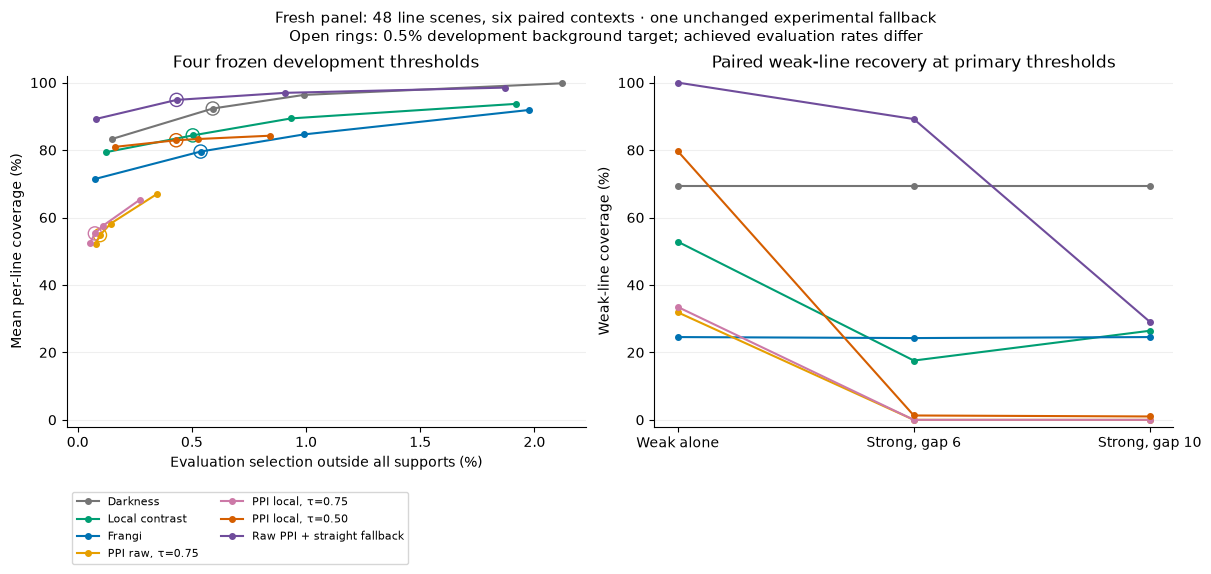

In [12]:
from benchmarks.plot_multiline import LABELS
from benchmarks.plot_path_diagnostics import plot_fallback

validation = json.loads((DIRECTORY / "fallback-validation.json").read_text())
assert validation["phase"] == "all"
assert len(validation["scenes"]) == 74 and len(validation["rows"]) == 2590
methods = validation["protocol"]["methods"]
assert len(methods) == 7
primary = [r for r in validation["rows"] if r["split"] == "evaluation"
           and r["selection"] == "frozen_threshold" and r["operating_point"] == .005]
assert len(primary) == 53 * len(methods)
assert len({(r["case_id"], r["method"]) for r in primary}) == len(primary)
labels = {**LABELS, "ppi_raw_straight_fallback": "Raw PPI + straight fallback"}
method_rows, control_rows = [], []
for method in methods:
    lines = [r for r in primary if r["method"] == method and r["metrics"]["has_target"]]
    controls = [r for r in primary if r["method"] == method and not r["metrics"]["has_target"]]
    assert len(lines) == 48 and len(controls) == 5
    cutoff = next(t["threshold"] for t in validation["thresholds"][method] if t["target_rate"] == .005)
    weak_means = []
    for family, gap, _ in scenarios:
        paired = [r for r in lines if r["family"] == family and r["gap"] == gap]
        assert len(paired) == 6
        weak_means.append(100 * np.mean([
            next(line["coverage"] for line in r["metrics"]["per_line"] if line["line_name"] == "weak")
            for r in paired]))
    method_rows.append([
        labels[method], f"{cutoff:.8g}",
        100 * np.mean([r["metrics"]["macro_coverage"] for r in lines]),
        100 * np.mean([r["metrics"]["worst_line_coverage"] for r in lines]),
        100 * np.mean([r["metrics"]["outside_support_fraction"] for r in lines]),
        np.mean([np.mean([line["longest_uncovered_arclength"]
                         for line in r["metrics"]["per_line"]]) for r in lines]),
        *weak_means,
    ])
    noise = [r["metrics"]["selected_pixels"] for r in controls if r["family"] == "noise"]
    blank_count = next(r["metrics"]["selected_pixels"] for r in controls if r["family"] == "blank")
    control_rows.append([labels[method], blank_count, np.mean(noise), min(noise), max(noise)])
table(["Method", "Cutoff", "Coverage (%)", "Worst line (%)", "Outside support (%)",
       "Mean longest gap (px)", "Weak alone (%)", "Weak gap 6 (%)", "Weak gap 10 (%)"], method_rows)
table(["Method", "Blank selected px", "Noise mean selected px", "Noise min px", "Noise max px"],
      control_rows)

# Precision is undefined if no pixel was selected; disclose the valid denominator.
precision_rows = []
for method in ("ppi_raw_default", "ppi_raw_straight_fallback"):
    metrics = [r["metrics"] for r in primary if r["method"] == method and r["metrics"]["has_target"]]
    defined = [m["union_centerline_precision"] for m in metrics
               if m["union_centerline_precision"] is not None]
    precision_rows.append([
        labels[method], 100 * np.mean([m["selected_fraction"] for m in metrics]),
        100 * np.mean(defined) if defined else None, len(defined), len(metrics),
    ])
table(["Method", "Mean selected ROI area (%)", "Centerline precision (%)",
       "Precision defined scenes", "All line scenes"], precision_rows)

# Secondary area-budget comparison: ties may exceed the nominal 2% area.
budget_rows = []
for method in ("ppi_raw_default", "ppi_raw_straight_fallback"):
    selected = [r for r in validation["rows"] if r["split"] == "evaluation"
                and r["selection"] == "area_budget" and r["operating_point"] == .02
                and r["method"] == method and r["metrics"]["has_target"]]
    assert len(selected) == 48
    weak_coverage = []
    for family, gap, _ in scenarios:
        paired = [r for r in selected if r["family"] == family and r["gap"] == gap]
        assert len(paired) == 6
        weak_coverage.append(100 * np.mean([
            next(line["coverage"] for line in r["metrics"]["per_line"] if line["line_name"] == "weak")
            for r in paired]))
    budget_rows.append([
        labels[method], 100 * np.mean([r["metrics"]["macro_coverage"] for r in selected]),
        100 * np.mean([r["metrics"]["selected_fraction"] for r in selected]),
        100 * np.mean([r["metrics"]["union_centerline_precision"] for r in selected]),
        *weak_coverage,
    ])
display(Markdown("**Secondary comparison: nominal 2% selected-area budget, including cutoff ties.**"))
table(["Method", "Coverage (%)", "Actual ROI area (%)", "Centerline precision (%)",
       "Weak alone (%)", "Weak gap 6 (%)", "Weak gap 10 (%)"], budget_rows)

for category, prefix in (("benchmark_source_sha256", "benchmarks"),
                         ("implementation_source_sha256", "src/polygonal_path_image")):
    for name, expected in validation["provenance"][category].items():
        assert hashlib.sha256((ROOT / prefix / name).read_bytes()).hexdigest() == expected, name
assert hashlib.sha256((DIRECTORY / "fallback-plan.json").read_bytes()).hexdigest() == \
       validation["protocol"]["predeclared_plan_sha256"]
display(Markdown(f"**Frozen experiment fingerprint:** `{validation['fingerprint']}`  \n"
                 f"**Validation JSON SHA-256:** `{hashlib.sha256((DIRECTORY / 'fallback-validation.json').read_bytes()).hexdigest()}`"))
fig = plot_fallback(validation)
plt.show()
plt.close(fig)

The fresh panel supports a useful but limited result: the fallback improves average line coverage and weak recovery at gap 6; gap 10 remains much less recovered. Its actual outside-support rate differs from the default PPI rate, and it selects 66–81 pixels on each noise-only control while raw default selects zero. Each control ROI contains 6400 pixels. The blank has zero pixels above the candidate's higher cutoff, which does **not** mean its vote map is zero.

The candidate also selects a broader area: **8.34%** of the ROI on average, versus **0.97%** for raw default. Mean precision within the 2-pixel centerline tube is **67.37%** for the candidate (48 defined scenes), versus **92.92%** for raw default (45 defined scenes; three empty selections excluded). Area means include all 48 line scenes. This denominator difference matters, and low selection outside the wider 3σ supports alone does not establish a thin, precise response.

**At the secondary nominal 2% area budget, the gain is not retained.** Candidate coverage is **76.62%**, versus **79.84%** for raw default; weak-line coverage beside the strong line is **0% at both gaps**, versus **7.00% and 7.19%** for raw default. Candidate weak-alone coverage remains 99.19%. Centerline precision instead rises to 97.60% versus 71.79%, with all 48 scenes defined; actual selected areas are 2.0189% versus 2.0837% because cutoff ties are included. The frozen-threshold improvement therefore depends on allowing larger selections; it does not establish better weak-line ranking within a tight pixel budget. Budget competition between strong and weak lines remains a separate limitation.

These measurements support further research on path selection under shape constraints, with curved/branch cases and noise behavior as guardrails. They do not establish a general fix, equal-background superiority, or a reason to change the published API defaults. The original Guide3D and multiline results are retained as separate, unchanged studies.